# **Automatidata project**
**Regression Analysis: Simplify complex data relationships**

# Build a multiple linear regression model

In [1]:
# Imports
# Packages for numerics + dataframes
import numpy as np
import pandas as pd

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for date conversions for calculating trip durations
import datetime

# Packages for OLS, MLR, confusion matrix
import statsmodels.api as sm 
import sklearn.metrics as metrics


In [2]:
# Load dataset into dataframe 
raw_df = pd.read_csv(r"Clean_2017_Taxi_Trip_Data.csv", index_col=0, 
                     parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'],
                     date_format="%Y-%m-%d %H:%M:%S") 

## Task 2. Data Wrangling

Take a quick look at the data structure and conduct tidying steps to improve data quality. 

In [3]:
# Exmaine the structure of data
raw_df.shape

(22698, 14)

In [4]:
# Examine the descriptive statistics of data
raw_df.describe(include=np.number)

,VendorID,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
count,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000,22698.000000
mean,1.556260,17.014605,1.643801,2.913441,1.039078,162.407877,161.523482,1.336902,13.031005,1.835862,0.312555,16.315701
std,0.496836,61.997769,1.283959,3.653200,0.281169,66.631429,70.137938,0.496217,13.205886,2.800661,1.399241,16.064197
min,1.000000,-17.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,6.600000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.000000,8.750000
50%,2.000000,11.200000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,1.350000,0.000000,11.800000
75%,2.000000,18.400000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,2.450000,0.000000,17.800000
max,2.000000,1439.600000,6.000000,33.960000,5.000000,265.000000,265.000000,4.000000,999.990000,200.000000,19.100000,1200.290000


### Outliers

The important columns to check for outliers are likely to be:
* `trip_distance`
* `fare_amount`
* `trip_duration`

### Task 2b. Box plots

Plot a box plot for each feature: `trip_distance`, `fare_amount`, `trip_duration`.

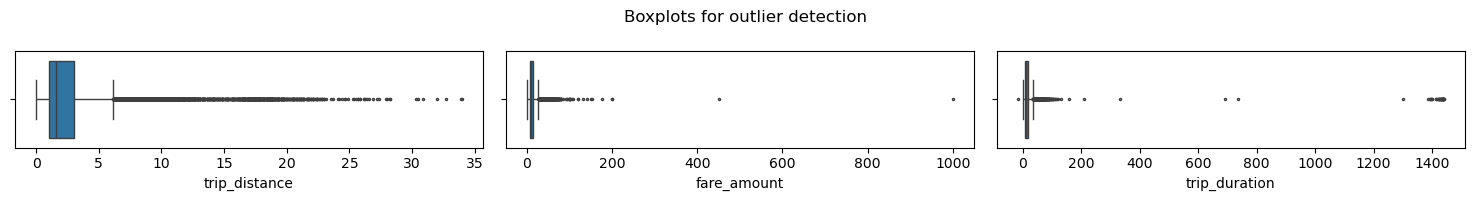

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 2))
fig.suptitle('Boxplots for outlier detection')
for i, col in enumerate(['trip_distance', 'fare_amount', 'trip_duration']):
    sns.boxplot(x=raw_df[col], fliersize=1.5, ax=ax[i])
fig.tight_layout()

1. It's 30 miles from the southern tip of Staten Island to the northern end of Manhattan and that's in a straight line. With this knowledge and the distribution of the values in this column, it's reasonable to leave these values alone and not alter them.
2. However, the values for `fare_amount` and `duration` seem to have problematic outliers on the higher end, which should be fixed.   

### Split data into training and test sets

To avoid data leakage, all preprocessing steps (imputations, scaling, extraction, transformation) that rely on statistics of the data ought to be conducted on the training set and transferred to the test set after the training pipeline is finalized.   

In [6]:
from sklearn.model_selection import train_test_split

# Create training and testing sets
train_set, test_set = train_test_split(raw_df, 
                                       test_size=0.2, 
                                       random_state=0, 
                                       stratify=raw_df['VendorID'])

### Task 2c. Imputations

#### `fare_amount` outliers

In [7]:
# Check the proportion of fare amount below cap of $62.50 
(train_set.fare_amount <= 62.5).mean()

0.9965855270404229

The range of values in the `fare_amount` column is large and the extremes don't make much sense.

- High values for this feature can be capped based on intuition and statistics. The upper bound of \$26.50 from standard formula seems too narrow. In this case, we'll use a factor of `6` at $62.5, which occupies majority of the values.

#### `trip_duration` outliers


The `trip_duration` column has problematic values at both the lower and upper extremities.

* **Low values:** Negative values can be misleading, as ML algorithms may learn that the predictions go beyond the 0 limit. Impute all negative durations with `0`.

* **High values:** Impute high values the same way as the high-end outliers for fares: `Q3 + (6 * IQR)`.

In [8]:
def feature_cap(df, column_list, iqr_factor=1.5):
    '''
    Impute upper-limit values in specified columns based on their interquartile range.

    Arguments:
        column_list: A list of columns to iterate over
        iqr_factor: int, float, dict, default 1.5
            A number representing x in the formula: Q3 + (x * IQR). 
            Used to determine maximum threshold, beyond which a point is 
            considered an outlier. If a dict is passed, the key is column
            to compute and the value is iqr factor. 

    The IQR is computed for each column in column_list and values exceeding
    the upper threshold for each column are imputed with the upper threshold value.
    '''
    copy_list = df.copy()
    
    for col in column_list:
        # Reassign minimum to zero
        copy_list[col] = np.where(copy_list[col] < 0, 0, copy_list[col])    

        try:
            # Calculate upper threshold
            iqr = copy_list[col].quantile(0.75) - copy_list[col].quantile(0.25)
            upper_thres = copy_list[col].quantile(0.75) + (iqr_factor * iqr)

            # Reassign values > threshold to threshold
            copy_list[col] = np.where(copy_list[col] > upper_thres, upper_thres, copy_list[col])

        except TypeError as err:
             # Calculate upper threshold
            iqr = copy_list[col].quantile(0.75) - copy_list[col].quantile(0.25)
            upper_thres = copy_list[col].quantile(0.75) + (iqr_factor[col] * iqr)

            # Reassign values > threshold to threshold
            copy_list[col] = np.where(copy_list[col] > upper_thres, upper_thres, copy_list[col])

    return copy_list

In [9]:
# Impute the outliers of duration & fare as Q3 + (6 * IQR)
train_set = feature_cap(train_set, 
                        [['fare_amount', 'trip_duration']], 
                        iqr_factor=6)

# Validate if all the outliers are rectified
print(train_set[['fare_amount', 'trip_duration']].describe())

        fare_amount  trip_duration
count  18158.000000   18158.000000
mean      12.893227      14.484134
std       10.543714      12.040273
min        0.000000       0.000000
25%        6.500000       6.600000
50%        9.500000      11.200000
75%       14.500000      18.400000
max       62.500000      89.200000


### Task 3. Feature engineering

#### Create `mean_distance` column

In [10]:
# Change Pick-up & Drop-off columns to string datatype and create a new composite column 
subset = train_set[['PULocationID', 'DOLocationID']]
train_set['PU_DO'] = subset.max(axis=1).astype(str) + ' ' + subset.min(axis=1).astype(str)

# Group by the unique pairs and compute the mean values
grouped = train_set[['PU_DO', 'trip_distance']].groupby('PU_DO').mean()
grouped.head()

,trip_distance
PU_DO,
1 1,2.433333
10 148,15.700000
100 1,16.890000


In [11]:
# Acquire the dict of index:value pairs from grouped dataframe for mapping 
grouped_dict = grouped['trip_distance'].to_dict()

In [12]:
# Map `grouped_dict` to the `mean_distance` column
train_set['mean_distance'] = train_set['PU_DO'].map(grouped_dict)

# Validate if mean_distance is created correctly 
train_set.loc[((train_set.PULocationID == 100) &
               (train_set.DOLocationID == 231)), 'mean_distance']

50574134    3.558
7282051     3.558
49385419    3.558
96629892    3.558
48945131    3.558
Name: mean_distance, dtype: float64

#### Create `mean_duration` column

In [13]:
grouped = train_set[['PU_DO', 'trip_duration']].groupby(by='PU_DO').mean()

grouped_dict = grouped['trip_duration'].to_dict()
train_set['mean_duration'] = train_set['PU_DO'].map(grouped_dict)

# Verify the feature engineering of mean_duration
train_set.loc[((train_set.PULocationID == 100) &
               (train_set.DOLocationID == 231)), 'mean_duration']

50574134    24.58
7282051     24.58
49385419    24.58
96629892    24.58
48945131    24.58
Name: mean_duration, dtype: float64

In [14]:
# Create a custom transformer to be trainable, learning some parameters 
# in the fit() and using them later in the transform() 

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column, agg_name):
        self.column = column
        self.agg_name = agg_name
    
    def fit(self, df, y=None):
        new_df = df.astype({'PULocationID': str, 'DOLocationID': str})
        new_df['PU_DO'] = new_df[['PULocationID','DOLocationID']].max(axis=1).astype(str) + \
            ' ' + new_df[['PULocationID','DOLocationID']].min(axis=1).astype(str)
        
        grouped = new_df[['PU_DO', self.column]].groupby('PU_DO').mean()
        self.grouped_dict_ = grouped[self.column].to_dict()
        
        return self

    def transform(self, df):
        check_is_fitted(self)
        new_df = df.copy()
        new_df['PU_DO'] = new_df[['PULocationID','DOLocationID']].max(axis=1).astype(str) + \
            ' ' + new_df[['PULocationID','DOLocationID']].min(axis=1).astype(str)
        new_df[self.agg_name] = new_df['PU_DO'].map(self.grouped_dict_)
        
        if new_df[self.agg_name].isna().any():
            new_df[self.agg_name] = new_df[self.agg_name].fillna(new_df[self.column])
        
        return new_df[self.agg_name].to_frame()

#### Create `rush_hour` column

In [15]:
# Create 'rush_hour' col
train_set['rush_hour'] = 0

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
weekend, peak_hours = ['Saturday', 'Sunday'], [6, 7, 8, 9, 16, 17, 18, 19] 

train_set.loc[(~train_set.tpep_pickup_datetime.dt.day_name().isin(weekend) &  
               train_set.tpep_pickup_datetime.dt.hour.isin(peak_hours)), 'rush_hour'] = 1

# Validate if 'rush_hour' column is implemented correctly
sample =  train_set.loc[train_set['rush_hour'] == 1, ['tpep_pickup_datetime', 'rush_hour']]
print(sample.tpep_pickup_datetime.dt.dayofweek.value_counts())

tpep_pickup_datetime
3    1115
2    1100
4    1073
1    1073
0    1026
Name: count, dtype: int64


In [16]:
def rushhour_encoder(df):
    '''
    Create a binary rush hour column that contains 1 if the ride was during 
    rush hour, such that any weekday (not Saturday or Sunday) 
    AND either from 06:00–10:00 or from 16:00–20:00. 

    Arguments:
        df: Pandas DataFrame
        column: Datetime column of DataFrame. Used to determine if 
                the pick-up time is during rush hour.   
    '''    
    weekend, peak_hours = ['Saturday', 'Sunday'], [6, 7, 8, 9, 16, 17, 18, 19]

    new_df = df.copy()    
    new_df['rush_hour'] = 0
    new_df.loc[(new_df['tpep_pickup_datetime'].dt.hour.isin(peak_hours) & 
            ~new_df['tpep_pickup_datetime'].dt.day_name().isin(weekend)), 'rush_hour'] = 1

    return new_df['rush_hour'].to_frame()

### Task 4. Feature Selection

Create a scatterplot to visualize the relationship between a numerical variable-`mean_duration` and target-`fare_amount`.

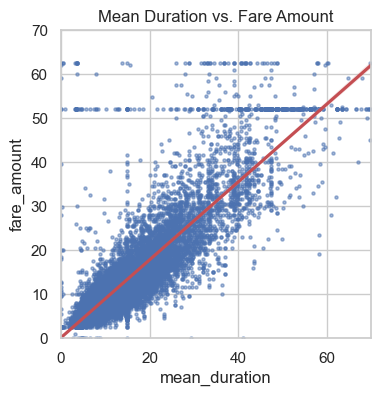

In [17]:
# Create a scatterplot for the variables
sns.set(style='whitegrid')
fig = plt.figure()
fig.set_figwidth(4)
fig.set_figheight(4)
sns.regplot(data=train_set, x='mean_duration', 
            y='fare_amount', ci=95,
            scatter_kws={'alpha': 0.5, 's': 5},
            line_kws={'color': 'r', 'ls': '--', 'lw': 1.0})
plt.ylim(0, 70); plt.xlim(0, 70)
plt.title('Mean Duration vs. Fare Amount')
plt.show()

The `mean_duration` variable correlates with the target variable. There are two horizontal lines around fare amounts of 52 dollars and 63 dollars. It's known that the top line represents \$62.50 maximum bounding value that was imputed for outliers.   
But what is the other line and how many are there?

In [18]:
# Examine the value of the rides in the 2nd horizontal lines in the scatterplot
train_set.loc[train_set.fare_amount > 50, 'fare_amount'].value_counts().head()

fare_amount
52.0    425
62.5     64
50.5      8
55.0      6
60.0      6
Name: count, dtype: int64

In [19]:
# Examine the first 30 of these trips 
pd.set_option('display.max_columns', None)
train_set[train_set.fare_amount == 52.0].head(30)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,PU_DO,mean_distance,mean_duration,rush_hour
66158440,2,2017-08-04 19:32:44,2017-08-04 20:24:03,51.3,1,17.64,2,132,230,2,52.0,0.00,5.76,63.06,132 230,18.171053,56.194737,1
21728806,1,2017-03-16 15:00:56,2017-03-16 16:12:28,71.5,1,16.80,2,230,132,1,52.0,11.65,5.54,69.99,230 132,18.181429,57.414286,0
796976,2,2017-01-03 18:04:42,2017-01-03 18:58:57,54.2,1,18.75,2,132,48,2,52.0,0.00,5.54,62.84,132 48,18.781667,58.222222,1
58516191,1,2017-07-09 18:21:17,2017-07-09 19:27:49,66.5,1,17.90,2,132,13,1,52.0,10.55,0.00,63.35,132 13,20.860000,51.333333,0
24632358,1,2017-03-24 16:23:46,2017-03-24 17:40:23,76.6,1,19.50,2,141,132,1,52.0,15.75,5.76,78.81,141 132,19.410000,62.250000,1
48641604,1,2017-06-05 05:15:32,2017-06-05 05:48:37,33.1,1,18.40,2,43,132,1,52.0,11.70,5.76,70.26,43 132,18.633333,43.966667,0
74720333,1,2017-09-06 10:46:17,2017-09-06 11:44:41,58.4,1,19.10,2,239,132,1,52.0,15.80,0.00,68.60,239 132,19.833333,56.133333,0
79314289,2,2017-09-21 07:33:48,2017-09-21 08:27:55,54.1,1,18.67,2,132,249,1,52.0,11.71,5.76,70.27,132 249,18.580000,46.850000,1
82786992,2,2017-10-02 14:18:42,2017-10-02 15:24:28,65.8,1,17.34,2,230,132,1,52.0,11.71,5.76,70.27,230 132,18.181429,57.414286,0
47187923,1,2017-06-01 14:55:43,2017-06-01 16:23:36,87.9,1,19.30,2,238,132,1,52.0,11.70,5.76,70.26,238 132,19.535000,64.300000,0


It seems that almost all of the trips in the first 30 rows where the fare amount was \$52 either begin or end at location 132, and all of them have a `RatecodeID` of 2.

The data dictionary says that `RatecodeID` of 2 indicates trips for JFK, which is John F. Kennedy International Airport. A quick Google search for "new york city taxi flat rate \$52" indicates that in 2017 (the year that this data was collected) there was indeed a flat fare for taxi trips between JFK airport (in Queens) and Manhattan.

Because `RatecodeID` is known from the data dictionary, the values for this rate code can be imputed back into the data after the model makes its predictions. This way we know that those data points will always be correct.

### Create Pipeline

Streamline the entire process of data wrangling and preprocessing steps. 

In [24]:
from sklearn.model_selection import train_test_split

# Create training and testing sets
train_set, test_set = train_test_split(raw_df, 
                                       test_size=0.2, 
                                       random_state=0, 
                                       stratify=raw_df['VendorID'])

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn import set_config
set_config(transform_output="pandas")

dist_transformer = CustomTransformer(column='trip_distance', agg_name='mean_distance')
dur_transformer = CustomTransformer(column='trip_duration', agg_name='mean_duration')

feature_engr = ColumnTransformer([
    ("agg1", dist_transformer, ['PULocationID', 'DOLocationID', 'trip_distance']),
    ("agg2", dur_transformer, ['PULocationID', 'DOLocationID', 'trip_duration']),
    ("enc", FunctionTransformer(rushhour_encoder), ['tpep_pickup_datetime', 'tpep_dropoff_datetime'])],
    remainder='passthrough', verbose_feature_names_out=False)

In [26]:
from sklearn.pipeline import Pipeline

limit_outliers = \
    FunctionTransformer(feature_cap, 
                        kw_args=dict(column_list=['fare_amount', 'trip_duration'],
                                    iqr_factor={'fare_amount': 6, 'trip_duration': 6}))
preprocessing = Pipeline([
    ("limit_outliers", limit_outliers), ("feature_engr", feature_engr)
])

In [27]:
# RUN THIS TO PREPARE DATA IN ONE-GO
train_set = preprocessing.fit_transform(train_set)
prep_test_set = preprocessing.transform(test_set)

train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18158 entries, 103809170 to 58943515
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_distance    18158 non-null  float64
 1   mean_duration    18158 non-null  float64
 2   rush_hour        18158 non-null  int64  
 3   VendorID         18158 non-null  int64  
 4   passenger_count  18158 non-null  int64  
 5   RatecodeID       18158 non-null  int64  
 6   payment_type     18158 non-null  int64  
 7   fare_amount      18158 non-null  float64
 8   tip_amount       18158 non-null  float64
 9   tolls_amount     18158 non-null  float64
 10  total_amount     18158 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 1.7 MB


### Task 4a. Isolate modeling variables

Drop features that are redundant, irrelevant, or that will not be available in a deployed environment.

In [29]:
for set_ in (train_set, prep_test_set):
    set_.drop(['RatecodeID', 'payment_type', 'tip_amount', 
               'tolls_amount', 'total_amount'], 
              axis=1, inplace=True)
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18158 entries, 103809170 to 58943515
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_distance    18158 non-null  float64
 1   mean_duration    18158 non-null  float64
 2   rush_hour        18158 non-null  int64  
 3   VendorID         18158 non-null  int64  
 4   passenger_count  18158 non-null  int64  
 5   fare_amount      18158 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 993.0 KB


### Task 4b. Check Model Assumptions

Examine distributions of features to model assumptions of regression, to determine if further feature transformation / extraction is necessary to allow the algorithm to leverage data in a suitable form. 

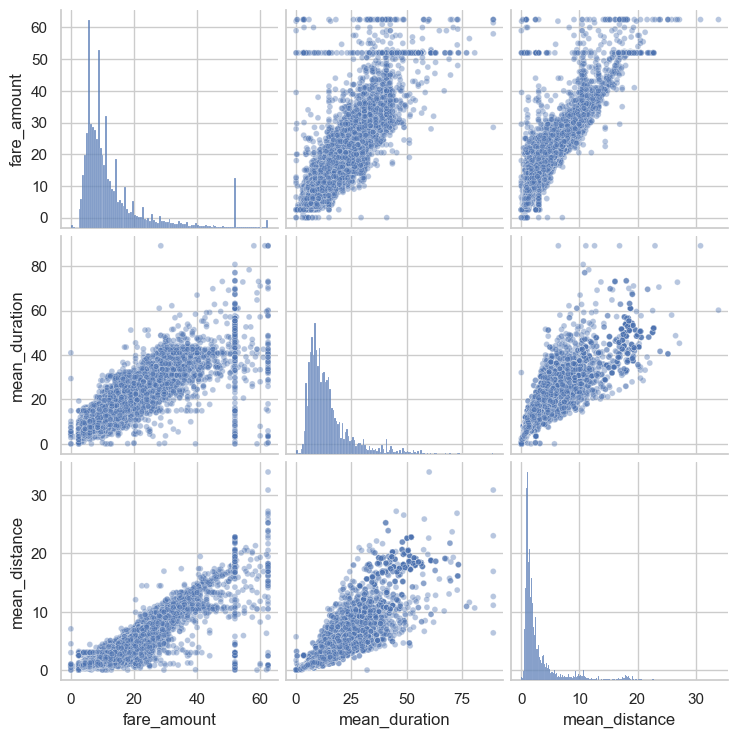

In [30]:
# Create a pairplot to visualize pairwise relationships between numerical variables
sns.pairplot(train_set[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha':0.4, 'size': 5})
plt.show()

These variables all show linear correlation with each other. Investigate this further.

In [32]:
# Correlation matrix to help determine most correlated variables
train_set.corr(method='pearson')['fare_amount']

mean_distance      0.911329
mean_duration      0.863813
rush_hour         -0.019431
VendorID           0.000582
passenger_count    0.016157
fare_amount        1.000000
Name: fare_amount, dtype: float64

Visualize a correlation heatmap of the data.

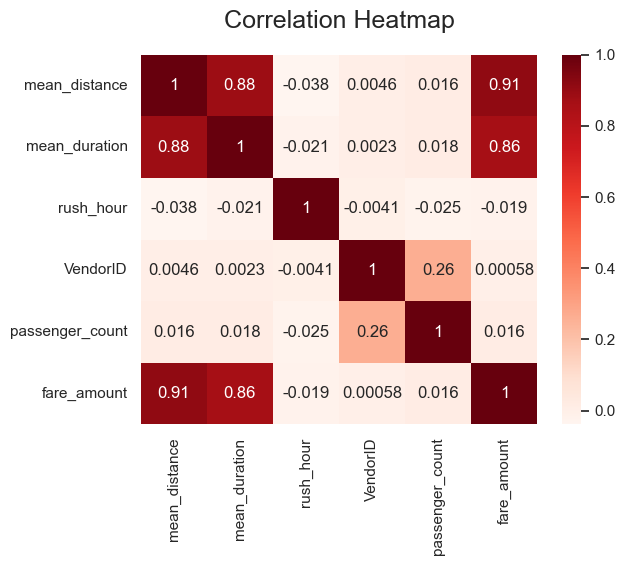

In [33]:
# Create correlation heatmap
sns.heatmap(train_set.corr(), annot=True, cmap='Reds')
plt.title('Correlation Heatmap', y=1.05, fontsize=18)
plt.show()

- Both `mean_distance` & `mean_duration` are highly correlated with `fare_amount`, but they are also correlated to each other. This is undesirable as it can introduce multi-collinearity to linear regression model. 
- While `passenger_count` & `rush_hour` do not illustrate a significant effect & strong association with the target, they may be ignored or used as covariates.

However, correlated predictor variables can still be used to create an accurate predictor if the prediction itself is more important than using the model as a tool to draw statistical inference about data.

Hence, try modeling with both variables even though they are correlated.

### Task 5a. Split data into outcome variable and features

In [34]:
# Split the selected features from 'df_model' into target & predictors
X_train = train_set.drop(columns=['fare_amount'])
X_test = prep_test_set.drop(columns=['fare_amount'])

y_train = train_set['fare_amount']
y_test = prep_test_set['fare_amount']

# Display first few rows
print(X_train, y_train, sep='\n\n')

           mean_distance  mean_duration  rush_hour  VendorID  passenger_count
103809170       1.043793       4.675862          0         1                1
91763727        3.138333      18.841667          1         1                1
100946927       8.932308      25.123077          0         1                1
20301907        2.938333      15.316667          0         2                1
39758657        0.937541       7.478689          1         1                1
...                  ...            ...        ...       ...              ...
113368135       1.007647      11.729412          0         1                1
23820525        1.906818      12.450000          0         2                1
92248051        0.931429       5.338095          0         1                1
64106266        8.500000      46.500000          1         1                3
58943515        6.113333      24.100000          0         2                6

[18158 rows x 5 columns]

103809170     5.5
91763727     13.0
1

### Task 5b. Pre-process data

Conduct feature scaling, encoding, and transformation that might be helpful to the algorithm.  

In [35]:
# Convert VendorID to string & OneHotEncoding
for set_ in (X_train, X_test):
    set_ = set_.astype({'VendorID': str})
    set_ = pd.get_dummies(set_, drop_first=True)

X_train

,mean_distance,mean_duration,rush_hour,VendorID,passenger_count
103809170,1.043793,4.675862,0,1,1
91763727,3.138333,18.841667,1,1,1
100946927,8.932308,25.123077,0,1,1
20301907,2.938333,15.316667,0,2,1
39758657,0.937541,7.478689,1,1,1
...,...,...,...,...,...
113368135,1.007647,11.729412,0,1,1
23820525,1.906818,12.450000,0,2,1
92248051,0.931429,5.338095,0,1,1
64106266,8.500000,46.500000,1,1,3


### Standardize the data

Scaling is often encouraged for optimization & distance-based solvers, although it may not be very effective here. 

In [36]:
from sklearn.preprocessing import StandardScaler

# Standardize the X variables
sc = StandardScaler()
X_train_scaled = pd.concat([sc.fit_transform(X_train[['mean_distance', 'mean_duration']]),
                            X_train.iloc[:, 2:]], axis=1)
X_train_scaled.head(3)

,mean_distance,mean_duration,rush_hour,VendorID,passenger_count
103809170,-0.525340,-0.977743,0,1,1
91763727,0.063493,0.434383,1,1,1
100946927,1.692337,1.060549,0,1,1


### Task 5c. Fit the model

In [37]:
multiple_regr = sm.OLS(y_train, X_train_scaled.assign(const=1))
model = multiple_regr.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                 1.997e+04
Date:                Thu, 16 Jan 2025   Prob (F-statistic):               0.00
Time:                        17:43:50   Log-Likelihood:                -51540.
No. Observations:               18158   AIC:                         1.031e+05
Df Residuals:                   18152   BIC:                         1.031e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
mean_distance       7.1383      0.066    108.638      0.000       7.009       7.267
mean_duration       2.7999      0.066     42.632      0.000       2.671       2.929
rush_hour           0.2791      0.067      4.149      0.000       0.147       0.411
VendorID           -0.0761      0.064     -1.189      0.235      -0.202       0.049
passenger_count     0.0157      0.025      0.628      0.530      -0.033       0.065
const              12.9031      0.104    123.995      0.000      12.699      13.107
==============================================================================
Omnibus:                    20577.694   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2899749.670
Skew:                           5.775   Prob(JB):                         0.00
Kurtosis:                      63.822   Cond. No.                         10.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Task 5d. Evaluate model

### Train data

In [45]:
# Evaluate the model performance on the training data
ytrain_preds = model.predict(X_train_scaled.assign(const=1)) 
R_squared = metrics.r2_score(y_train, ytrain_preds)
MAE = metrics.mean_absolute_error(y_train, ytrain_preds)
MSE = metrics.mean_squared_error(y_train, ytrain_preds)

print(f'R_squared: {R_squared:.3f}, MAE: {MAE:.3f}, MSE: {MSE:.3f}')

R_squared: 0.846, MAE: 2.213, MSE: 17.099


- MAE gives a realistic estimate that the model is off by /$2.213 dollars on average, without reflecting the severity of the worst errors. 
- The MSE is much higher than MAE, which suggests that the model has some large errors that inflate it. These could be due to outliers, noise, or nonlinearity in the data.     

### Test data

Calculate the same metrics on the test data. Remember to scale the `X_test` data using the scaler that was fit to the training data.

In [46]:
# Scale the X_test data
X_test_scaled = pd.concat([sc.transform(X_test[['mean_distance', 'mean_duration']]), 
                           X_test.iloc[:, 2:]], axis=1)
X_test_scaled.head(3)

,mean_distance,mean_duration,rush_hour,VendorID,passenger_count
87225995,-0.081382,0.296651,1,1,1
64638886,-0.344184,-0.276028,0,2,6
43194373,-0.507602,-0.371685,0,2,2


In [47]:
# Evaluate the model performance on the testing data
ytest_preds = model.predict(X_test_scaled.assign(const=1)) 
R_squared = metrics.r2_score(y_test, ytest_preds)
MAE = metrics.mean_absolute_error(y_test, ytest_preds)
MSE = metrics.mean_squared_error(y_test, ytest_preds)

print(f'R_squared: {R_squared:.3f}, MAE: {MAE:.3f}, MSE: {MSE:.3f}')

R_squared: 0.813, MAE: 2.434, MSE: 20.624


**Note:** The model performance is high on both training & test sets, 
indicating that there is little bias in the model and that model is not overfit. 

The mean absolute error (MAE) is informative here because it allows us to assess whether the squared evaluation metric (MSE) for the model is heavily affected by the outliers in smaller test set compared to the larger training set. 

In [40]:
# Save a copy of the data for future analysis
train_data = pd.DataFrame({'mean_duration': X_train['mean_duration'], 
                           'mean_distance': X_train['mean_distance'],
                           'predicted_fare': ytrain_preds})

test_data = pd.DataFrame({'mean_duration': X_test['mean_duration'], 
                          'mean_distance': X_test['mean_distance'],
                          'predicted_fare': ytest_preds})

regr_predictors = pd.concat([test_data, train_data], axis=0)

In [65]:
regr_predictors.to_csv('nyc_selfpreds_means.csv', index=True)

### Task 6a. Examine Model Results

Conduct regression diagnostics on linearity & OLS model assumptions. 

In [48]:
# Create a `results` dataframe
results = pd.DataFrame({'actual': y_test, 
                        'predicted': ytest_preds,
                        'residual': y_test - ytest_preds})
results

,actual,predicted,residual
87225995,12.0,13.371485,-1.371485
64638886,8.0,9.615223,-1.615223
43194373,6.0,8.118176,-2.118176
72366830,7.5,7.018494,0.481506
61189839,9.5,11.072984,-1.572984
...,...,...,...
1641445,7.5,6.830173,0.669827
87775263,15.5,12.932566,2.567434
47827064,6.0,6.537482,-0.537482
76874564,52.0,56.584510,-4.584510


### Task 6b. Visualize model results

### Linearity

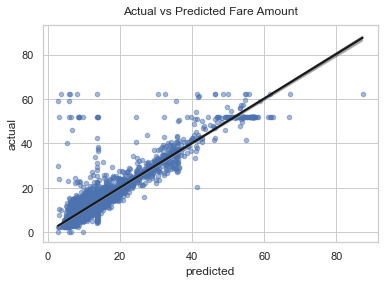

In [60]:
# Create a scatterplot to visualize `predicted` over `actual`
ax = sns.regplot(x=results.predicted, y=results.actual, ci=95,
                scatter_kws={'alpha': 0.5, 's': 20}, line_kws={'color': 'k'})
plt.setp(ax.collections[1], alpha=0.4)
plt.title('Actual vs Predicted Fare Amount', y=1.02)
plt.show()

### Normality of errors

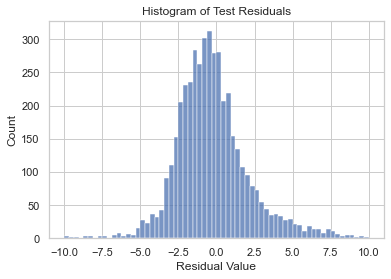

In [61]:
# Visualize the distribution of the `residuals`
norm_fig = sns.histplot(results.residual, bins='auto', binrange=[-10, 10])
plt.title('Histogram of Test Residuals')
plt.xlabel('Residual Value'); plt.ylabel('Count')
plt.show()

In [49]:
# Calculate residual mean
residual_mean = results['residual'].mean() 
residual_mean

0.05648293996091056

- The residuals represent the variance in the outcome variable that is not explained by the model. A normal distribution around zero is good, as it demonstrates that the model's errors are evenly distributed and unbiased.

### Homoskedasticity

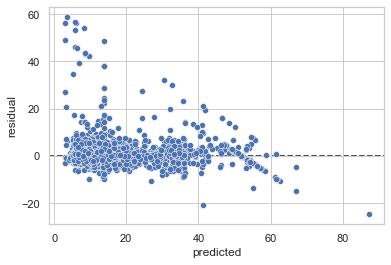

In [63]:
# Create a scatterplot of `residuals` over `predicted`
resid_plot = sns.scatterplot(x='predicted', y='residual', data=results)
resid_plot.axhline(0, ls='--', color='k', zorder=0)
plt.show()

- The model's residuals are evenly distributed around the mean of 0, (complying with the Homoscedascity & Independent observations assumptions) with the exception of the sloping points from the upper-left to the lower-right corner, which are known as the imputed maximum value of \\$62.50 & the flat rate of \\$52 for JFK airport from the EDA earlier. 

### Task 6c. Coefficients

In [62]:
# Evaluate model's coefficients to determine which feature 
# had the greatest effect on trip fare 
model.params

mean_distance       7.138275
mean_duration       2.799864
rush_hour           0.279140
VendorID           -0.076117
passenger_count     0.015675
const              12.903129
dtype: float64

**Note:** As `mean_duration` & `mean_distance` were scaled earlier, a common misinterpretation can occur if we're to treat them equally. This is because they are no longer miles or minutes.

**Translate standardized variables**

In [63]:
# To translate coefficients back to miles instead of S.D (unscaled):
# 1. Calculate SD of the feature in X_train data
print(f'S.D -dist: {X_train['mean_distance'].std()}', 
      f'S.D -duration: {X_train['mean_duration'].std()}')

# 2. Divide the model coefficient by the standard deviation
print('\n Unstandardized Coefficients:')
print(model.params.iloc[0] / X_train['mean_distance'].std(), 
      model.params.iloc[1] / X_train['mean_duration'].std())

S.D -dist: 3.5572060449702905 S.D -duration: 10.031817496656686

 Unstandardized Coefficients:
2.0067083709121056 0.27909835645792225


#### Now, a more intuitive interpretation can be made for all the coefficients.

- &emsp;  For every mile in the mean distance of a trip, the fare amount is expected to raise by 2 dollars on average, while holding other variables constant. Or, for every 3.56 miles traveled, the fare is increased by a mean of 7.13 dollars.<br>

- &emsp; On average, a delay on any given trip is expected to raise the fare amount by 28 pennies with every minute that goes by irrespective of the mean distance, vendor, and hour of the day.<br>

- &emsp; On average, a trip offered by VeriFone Inc. is expected to command a fare amount of roughly 7 pennies lower than a trip in Creative Mobile Technologies.<br>

- &emsp; For a trip during rush hour, it is expected to command a fare amount of a quarter higher than normal hour on average, while holding other variables constant.  

# NOTES

For best practices on how tasks are typically performed:

- It would be better to separate the rides that did *not* have rate codes of 2, train the model on that data specifically, and then add the `RatecodeID 2` data (and its imputed rates) *after*. This would prevent training the model on data that do not need a model for, and it would likely result in a better final model. However, the steps were combined for simplicity.